In [30]:
import os 
from pathlib import Path
import sys
from typing import Dict, List, Tuple, Optional

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [CWD, *CWD.parents] if (candidate / "scripts").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate pcmdi_package/scripts.")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from pcmdi_enso_reader import ENSODiagReader
from enso_feature_sources import (
    EnsembleSource, load_ensemble_variable, load_pcmdi_variable,
)
from metrics_group_merger import PCMDIRun


In [31]:
class ENSOStaPlotter:
    """
    Plot diagnostics for ENSO diversity metrics from `data_dict`.

    Expected data_dict structure:
        data_dict[var_name] = {
            "reference": DataArray(sample, ...),
            "hist":      DataArray(sample, ...),
            "future":    DataArray(sample, ...),
        }
    """

    def __init__(
        self,
        data_dict,
        target_group="ENSO_perf",
        target_metric="enso_sst_diversity_mode2",
        fig_dir=".",
        fig_fmt="png",
    ):
        self.data_dict = data_dict
        self.target_group = target_group
        self.target_metric = target_metric
        self.fig_dir = fig_dir
        self.fig_fmt = fig_fmt

        os.makedirs(self.fig_dir, exist_ok=True)

    # -----------------------------
    # Internal helpers
    # -----------------------------
    def _get_values(self, var, group):
        """Return 1D np.ndarray of non-NaN values for a given variable & group."""
        da = self.data_dict[var][group]
        vals = da.values.ravel()
        return vals[~np.isnan(vals)]

    def compute_custom_box_stats(self, vals, label):
        """
        Custom boxplot statistics for matplotlib.bxp:
          - q1  = 5th percentile
          - med = median
          - q3  = 95th percentile
          - whislo  = min(vals)
          - whishi  = max(vals)
        """
        vals = np.asarray(vals)
        vals = vals[~np.isnan(vals)]

        if vals.size == 0:
            raise ValueError(f"No valid data for {label} (all NaN or empty).")

        stats = {
            "label": label,
            "mean": float(np.mean(vals)),
            "med": float(np.median(vals)),
            "q1": float(np.percentile(vals, 5)),
            "q3": float(np.percentile(vals, 95)),
            "whislo": float(vals.min()),
            "whishi": float(vals.max()),
            "fliers": [],
        }
        return stats
        
    @staticmethod
    def _format_lon(lon):
        """
        Format longitude in 0–360 degrees as E/W.
        """
        lon = float(lon)
        
        if np.isnan(lon):
            return ""
    
        if lon == 0 or lon == 360:
            return "0°"
            
        if lon == 180:
            return "180°"
    
        if lon < 180:
            return f"{int(lon)}°E"
        else:
            return f"{int(360 - lon)}°W"

    # -----------------------------
    # Single-panel, all variables
    # -----------------------------
    def plot_enso_lon_box(
        self,
        variables=None,
        title=None,
        xlabel="",
        ylabel="Diagnostic value",
        ylim=None,
        figsize=None,
        figgrps=None,
        figdict=None,
        format_lon=False,
        fig_dpi=150,
        fig_format='png',
        fname=None,
        var_labels=None,
        font_size=12,
        group_spacing=1.4,     # ★ NEW: spacing between groups (default > 1 for wider gaps)
    ):
        """
        Plot all variables in one panel using custom percentiles:
          - Q1 = 5th percentile
          - Q2 = median
          - Q3 = 95th percentile
          - whiskers = min, max
        """
        
        # Variables to plot
        if variables is None:
            variables = list(self.data_dict.keys())

        data_dict = self.data_dict
        ngroups = len(variables)
        width = 0.25
        
        #x0 = np.arange(ngroups)
        x0 = np.arange(ngroups) * group_spacing

        if figsize is None:
            figsize = (1.6 * ngroups + 3, 6)

        fig = plt.figure(figsize=figsize)
        # Force fixed subplot geometry (critical for combined layout)
        gs = fig.add_gridspec(
            1, 1,
            left=0.18,    # margin left
            right=0.97,   # margin right
            bottom=0.16,  # margin bottom
            top=0.90      # margin top
        )
        
        ax = fig.add_subplot(gs[0, 0])

        # --- font sizes ---
        ax.set_xlabel(xlabel, fontsize=font_size * 1.0)
        ax.set_ylabel(ylabel, fontsize=font_size * 1.0)
        ax.set_title(title, fontsize=font_size * 1.1, loc="left")
        ax.tick_params(
            axis="both", 
            length=8,         # tick length (points)
            width=0.8,        # tick line width
            direction="out",  # or "in", "inout"
            labelsize=font_size * 0.95
        )

        # Loop through variables and groups
        legend_labels = {}
        for i, var in enumerate(variables):
            for j, group in enumerate(figgrps):

                vals = self._get_values(var, group)
                stats = self.compute_custom_box_stats(vals, label=f"{var}-{group}")

                xpos = x0[i] + (j - 1) * width  # left/center/right offset
                color = figdict[group]['color']
                alpha = figdict[group]['alpha'] 
                if group not in legend_labels:
                    legend_labels[group] = figdict[group]['label']
                    
                bp = ax.bxp(
                    [stats],
                    positions=[xpos],
                    widths=width * 0.8,
                    showmeans=True,
                    meanprops=dict(
                        marker="o",
                        markerfacecolor=color,
                        markeredgecolor=color,
                        markersize=7,
                        markeredgewidth=0
                    ),
                    medianprops=dict(
                        color=color, 
                        linewidth=2
                    ),                 
                    patch_artist=True,
                )

                for patch in bp["boxes"]:
                    patch.set_facecolor(color)
                    patch.set_alpha(alpha)

        # x-axis labels (optionally mapped through var_labels)
        xticklabels = []
        for var in variables:
            if isinstance(var_labels, dict):
                xticklabels.append(var_labels.get(var, var))
            else:
                xticklabels.append(var)

        ax.set_xticks(x0)
        ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=font_size)

        yticks = ax.get_yticks()
        ax.set_yticks(yticks) 

        if format_lon:
            ax.set_yticklabels([self._format_lon(t) for t in yticks], fontsize=font_size*0.95)
        else:
            ax.set_yticklabels([t for t in yticks], fontsize=font_size*0.95)

        # y-limits
        if ylim is not None:
            ax.set_ylim(*ylim)
            
        # Grid & layout
        ax.grid(True, linestyle="--", alpha=0.4)
        # Legend
        handles = [
            Patch(facecolor=figdict[g]['color'], alpha=figdict[g]['alpha'] , edgecolor="black", label=g)
            for g in figgrps
        ]
        
        handle_labels = [legend_labels[key] for key in legend_labels]
        ax.legend(
            handles, handle_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=max(1, (len(handles) + 1) // 2),
            frameon=True,
            fontsize=font_size * 0.9,
        )

        fig.subplots_adjust(
            left=0.22, right=0.97, bottom=0.32, top=0.90
        )
        
        out_path = os.path.join(self.fig_dir, fname)
        fig.savefig(
            out_path, 
            dpi=fig_dpi, 
            format=fig_format, 
            bbox_inches="tight", 
            pad_inches=0.05
        )
        print("Saved figure:", out_path)
        plt.show()
        plt.close(fig)
        

processing period: hist
enso_sst_diversity_mode2/Enso_lon_pos_maxSSTA/historical: case=v20260212, shape=(411,)
processing period: future
enso_sst_diversity_mode2/Enso_lon_pos_maxSSTA/future: case=v20260212, shape=(410,)
processing period: hist
enso_sst_diversity_mode2/Nina_lon_pos_minSSTA/historical: case=v20260212, shape=(210,)
processing period: future
enso_sst_diversity_mode2/Nina_lon_pos_minSSTA/future: case=v20260212, shape=(197,)
processing period: hist
enso_sst_diversity_mode2/Nino_lon_pos_maxSSTA/historical: case=v20260212, shape=(201,)
processing period: future
enso_sst_diversity_mode2/Nino_lon_pos_maxSSTA/future: case=v20260212, shape=(213,)
Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_sst_diversity_mode2_historical_vs_future.pdf


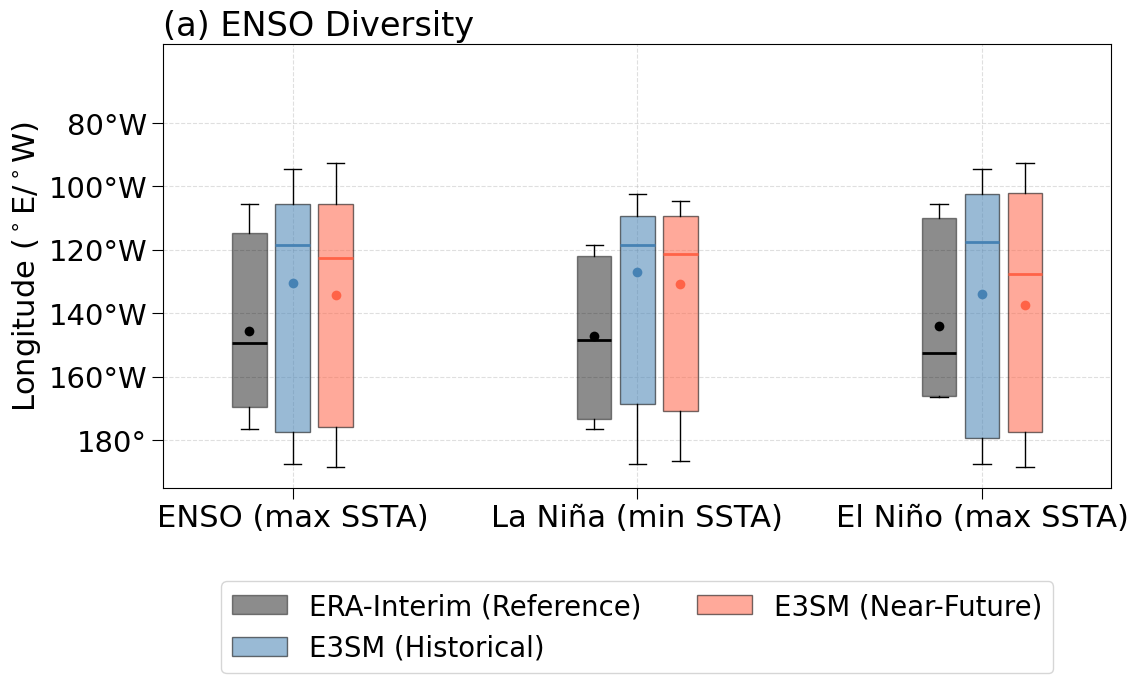

processing period: hist
enso_duration/Nina_duration/historical: case=v20260212, shape=(210,)
processing period: future
enso_duration/Nina_duration/future: case=v20260212, shape=(197,)
processing period: hist
enso_duration/Nino_duration/historical: case=v20260212, shape=(201,)
processing period: future
enso_duration/Nino_duration/future: case=v20260212, shape=(213,)
Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_duration_historical_vs_future.pdf


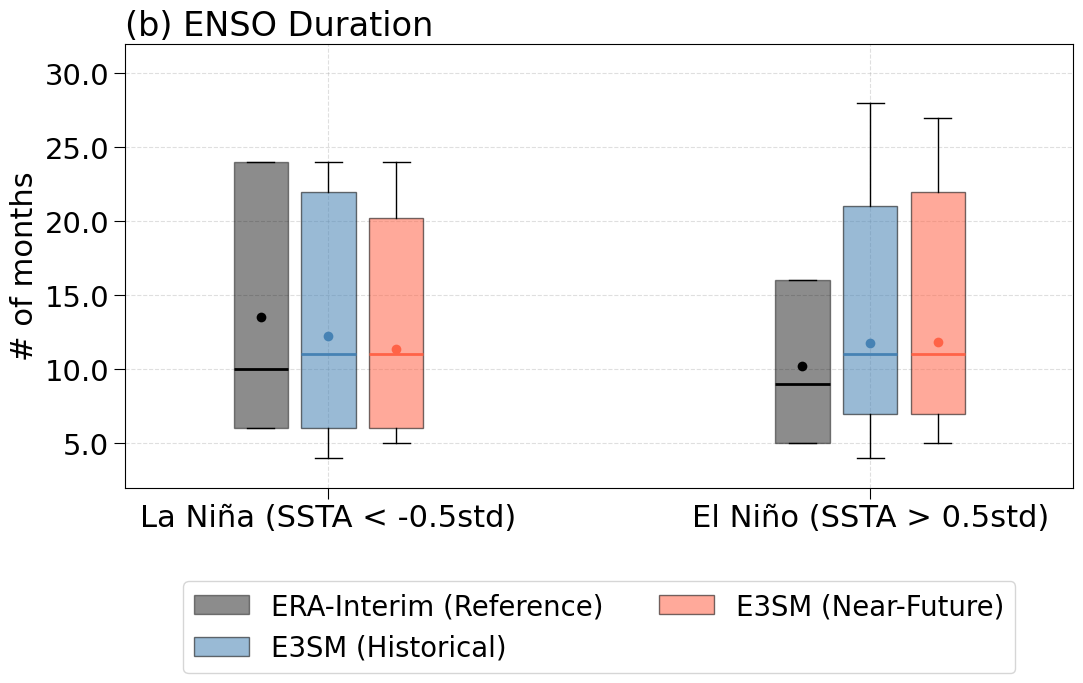

In [32]:
# =====================================================================
# SETUP / CONFIGURATION
# =====================================================================

# --- Paths ----------------------------------------------------------------
DATA_DIR = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le")
FIG_DIR = DATA_DIR / "paper_plot"

# --- Run / diagnostic settings ----------------------------------------------
RUN_PLOTS = True
READER_VERBOSE = False
DIAGNOSTIC_PRINT = True
POOL_MEMBERS_TO_SAMPLES = True

# --- Reference settings ------------------------------------------------------
REFERENCE_SET = "ERA-Interim"
DEFAULT_CASE_ID = "v20260212"
REFERENCE_SETS = {"ERA-Interim": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"}}

# --- Comparison groups (ensembles / runs to compare) --------------------------
COMPARISON_GROUPS = [
    {
        "key": "historical", "label": "E3SM (Historical)", "color": "steelblue",
        "source": EnsembleSource(DATA_DIR, "v3.LR.historical", "hist", (1985, 2014), 25),
    },
    {
        "key": "future", "label": "E3SM (Near-Future)", "color": "tomato",
        "source": EnsembleSource(DATA_DIR, "v3.LR.historical", "future", (2015, 2049), 25),
    },
]

# --- Figure numbering -----------------------------------------------------
FIG_INDEX_START = 0

# --- Box plot styling settings ----------------------------------------------
REFERENCE_COLOR = "black"
REFERENCE_ALPHA = 0.45
GROUP_ALPHA = 0.55
BOX_FIGSIZE = (12, 6)
BOX_FONT_SIZE = 22
BOX_GROUP_SPACING = 2
FIG_DPI = 300
FIG_FORMAT = "pdf"

# --- Per-metric plot configs ------------------------------------------------
TARGET_METRICS = {
    "enso_sst_diversity_mode2": {
        "group": "ENSO_perf",
        "suffix": "EnsoSstDiversity_2",
        "variables": {
            "Enso_lon_pos_maxSSTA": "ENSO (max SSTA)",
            "Nina_lon_pos_minSSTA": "La Niña (min SSTA)",
            "Nino_lon_pos_maxSSTA": "El Niño (max SSTA)",
        },
        "label": "ENSO Diversity",
        "unit": r"Longitude ($^\circ$E/$^\circ$W)",
        "ylim": (165, 305),
        "rtol": 1e-2,
        "format_lon": True,
    },
    "enso_duration": {
        "group": "ENSO_perf",
        "suffix": "EnsoDuration",
        "variables": {
            "Nina_duration": "La Niña (SSTA < -0.5std)",
            "Nino_duration": "El Niño (SSTA > 0.5std)",
        },
        "label": "ENSO Duration",
        "unit": "# of months",
        "ylim": (2, 32),
        "rtol": 1e-2,
        "format_lon": False,
    },
}


# =====================================================================
# FUNCTIONS
# =====================================================================

def run_box_comparison(groups, output_suffix=""):
    keys = [x["key"] for x in groups]
    if not keys or len(keys) != len(set(keys)):
        raise ValueError(f"Invalid comparison keys: {keys}")

    styles = {
        "reference": {"label": f"{REFERENCE_SET} (Reference)", "color": REFERENCE_COLOR, "alpha": REFERENCE_ALPHA},
        **{x["key"]: {"label": x["label"], "color": x["color"], "alpha": GROUP_ALPHA} for x in groups},
    }

    outputs = []
    for mi, (metric, cfg) in enumerate(TARGET_METRICS.items()):
        metric_data = {}
        for var in cfg["variables"]:
            vardata = {}
            refs = []
            for item in groups:
                src = item["source"]
                if isinstance(src, EnsembleSource):
                    model, ref, cid = load_ensemble_variable(
                        src, metric, cfg, var,
                        REFERENCE_SETS[REFERENCE_SET][src.group],
                        DEFAULT_CASE_ID,
                        verbose=READER_VERBOSE,
                        pool_members=POOL_MEMBERS_TO_SAMPLES,
                    )
                elif isinstance(src, PCMDIRun):
                    model, ref, cid = load_pcmdi_variable(src, cfg, var, item.get("obs_tag"))
                else:
                    raise TypeError("source must be EnsembleSource or PCMDIRun")

                vardata[item["key"]] = model
                refs.append(ref)
                if DIAGNOSTIC_PRINT:
                    print(f"{metric}/{var}/{item['key']}: case={cid}, shape={model.shape}")

            refs = xr.align(*refs, join="exact")
            if any(not np.allclose(refs[0], r, rtol=cfg["rtol"], atol=0, equal_nan=True) for r in refs[1:]):
                raise ValueError(f"{metric}/{var}: inconsistent references")

            vardata["reference"] = refs[0]
            metric_data[var] = vardata

        tag = "_vs_".join(keys)
        plotter = ENSOStaPlotter(metric_data, cfg["group"], metric, FIG_DIR, fig_fmt=FIG_FORMAT)
        outputs.append(
            plotter.plot_enso_lon_box(
                variables=list(cfg["variables"]),
                title=f"({chr(mi + FIG_INDEX_START + 97)}) {cfg['label']}",
                xlabel="",
                ylabel=cfg["unit"],
                ylim=cfg["ylim"],
                figsize=BOX_FIGSIZE,
                figdict=styles,
                figgrps=["reference", *keys],
                fname=f"enso_{metric}_{tag}{output_suffix}.pdf",
                var_labels=cfg["variables"],
                font_size=BOX_FONT_SIZE,
                format_lon=cfg["format_lon"],
                group_spacing=BOX_GROUP_SPACING,
                fig_dpi=FIG_DPI,
                fig_format=FIG_FORMAT,
            )
        )
    return outputs


# =====================================================================
# EXECUTION
# =====================================================================

if RUN_PLOTS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    run_box_comparison(COMPARISON_GROUPS)
else:
    print("Set RUN_PLOTS = True after reviewing COMPARISON_GROUPS.")

enso_sst_diversity_mode2/Enso_lon_pos_maxSSTA/v3lr_0051: case=v20260212, shape=(1, 17)
enso_sst_diversity_mode2/Enso_lon_pos_maxSSTA/v3lr_0091: case=v20260212, shape=(1, 20)
enso_sst_diversity_mode2/Enso_lon_pos_maxSSTA/v3lr_0101: case=v20260212, shape=(1, 15)
enso_sst_diversity_mode2/Enso_lon_pos_maxSSTA/v3lr_0111: case=v20260212, shape=(1, 17)
enso_sst_diversity_mode2/Nina_lon_pos_minSSTA/v3lr_0051: case=v20260212, shape=(1, 10)
enso_sst_diversity_mode2/Nina_lon_pos_minSSTA/v3lr_0091: case=v20260212, shape=(1, 9)
enso_sst_diversity_mode2/Nina_lon_pos_minSSTA/v3lr_0101: case=v20260212, shape=(1, 9)
enso_sst_diversity_mode2/Nina_lon_pos_minSSTA/v3lr_0111: case=v20260212, shape=(1, 9)
enso_sst_diversity_mode2/Nino_lon_pos_maxSSTA/v3lr_0051: case=v20260212, shape=(1, 7)
enso_sst_diversity_mode2/Nino_lon_pos_maxSSTA/v3lr_0091: case=v20260212, shape=(1, 11)
enso_sst_diversity_mode2/Nino_lon_pos_maxSSTA/v3lr_0101: case=v20260212, shape=(1, 6)
enso_sst_diversity_mode2/Nino_lon_pos_maxSSTA/v3

Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_sst_diversity_mode2_v3lr_0051_vs_v3lr_0091_vs_v3lr_0101_vs_v3lr_0111_standalone.pdf


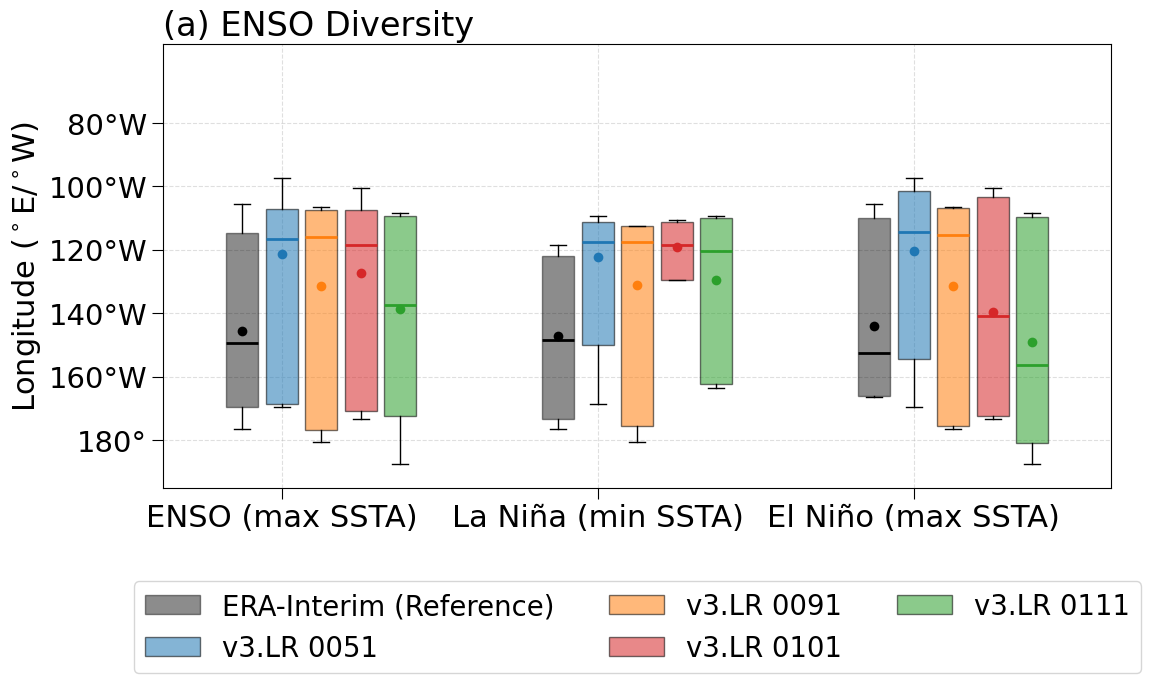

enso_duration/Nina_duration/v3lr_0051: case=v20260212, shape=(1, 10)
enso_duration/Nina_duration/v3lr_0091: case=v20260212, shape=(1, 9)
enso_duration/Nina_duration/v3lr_0101: case=v20260212, shape=(1, 9)
enso_duration/Nina_duration/v3lr_0111: case=v20260212, shape=(1, 9)
enso_duration/Nino_duration/v3lr_0051: case=v20260212, shape=(1, 7)
enso_duration/Nino_duration/v3lr_0091: case=v20260212, shape=(1, 11)
enso_duration/Nino_duration/v3lr_0101: case=v20260212, shape=(1, 6)
enso_duration/Nino_duration/v3lr_0111: case=v20260212, shape=(1, 8)
Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_duration_v3lr_0051_vs_v3lr_0091_vs_v3lr_0101_vs_v3lr_0111_standalone.pdf


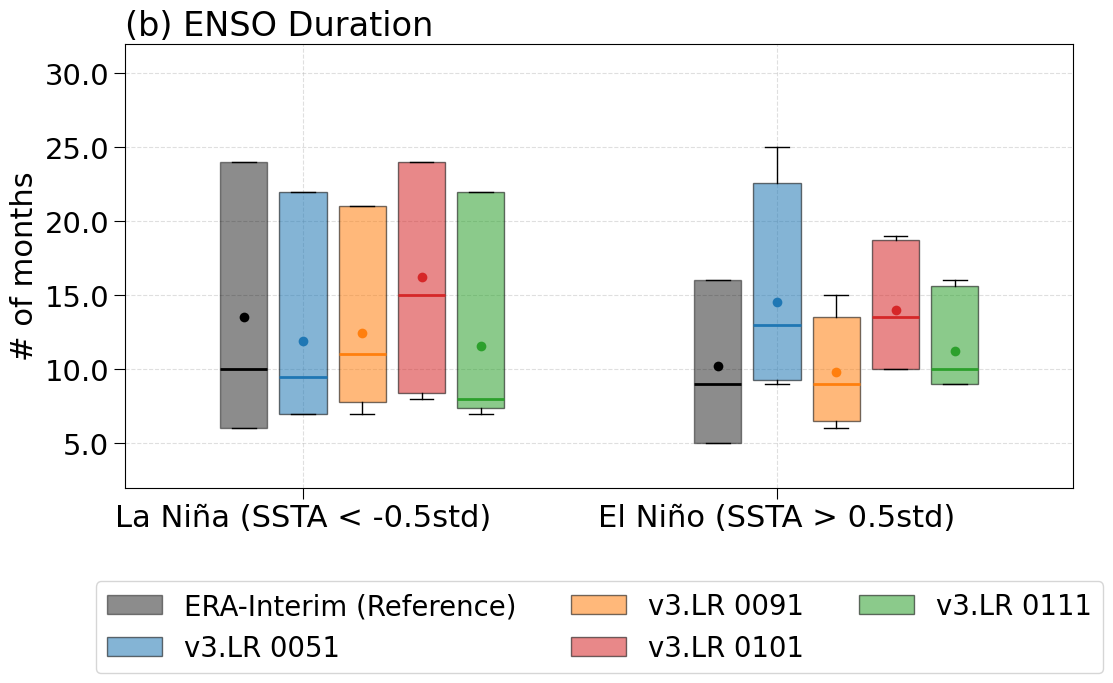

In [33]:
# =====================================================================
# STANDALONE PCMDI-RUN TEST (one member per plotted group)
# =====================================================================
# Overrides COMPARISON_GROUPS above to compare four individual v3.LR
# historical members directly, rather than pooled ensembles.

# --- Setup / configuration --------------------------------------------
RUN_STANDALONE_PLOTS = True
STANDALONE_INPUT_DIR = DATA_DIR / "hist"
STANDALONE_OUTPUT_SUFFIX = "_standalone"

STANDALONE_MEMBERS = [
    {"key": "v3lr_0051", "label": "v3.LR 0051", "color": "tab:blue", "case": "v3.LR.historical_0051", "model_name": "v3-LR_0051"},
    {"key": "v3lr_0091", "label": "v3.LR 0091", "color": "tab:orange", "case": "v3.LR.historical_0091", "model_name": "v3-LR_0091"},
    {"key": "v3lr_0101", "label": "v3.LR 0101", "color": "tab:red", "case": "v3.LR.historical_0101", "model_name": "v3-LR_0101"},
    {"key": "v3lr_0111", "label": "v3.LR 0111", "color": "tab:green", "case": "v3.LR.historical_0111", "model_name": "v3-LR_0111"},
]
STANDALONE_METRICS_CASE_ID = "v20260212"

#OUT_FIG_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/enso_feature_metrics")
#INPUT_DATA_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi")
# Example: four standalone PCMDI runs (one member per plotted group).
# COMPARISON_GROUPS = [
#     {"key": "v3_lr", 
#      "label": "v3.LR.CPL", 
#      "color": "tab:blue",
#      "source": PCMDIRun(case="20231209.v3.LR.piControl-spinup.chrysalis",
#                         model_name="EAMXX-ne256_coupled-test", 
#                         metrics_case_id="v20260531",
#                         output_name="v3.LR.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v3_hr", 
#      "label": "v3.HR.CPL", 
#      "color": "tab:orange",
#      "source": PCMDIRun(case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
#                         model_name="v3-HR_test6-1", 
#                         metrics_case_id="v20260601",
#                         output_name="v3.HR.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v4p", 
#      "label": "v4P.CPL",
#      "color": "tab:red",
#      "source": PCMDIRun(case="20260204.ne256.WCYCLXX1850.SOI",
#                         model_name="EAMXX-ne256_coupled-test", 
#                         metrics_case_id="v20260601",
#                         output_name="v4P.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v4p_amip", 
#      "label": "v4P.AMIP",
#      "color": "tab:green",
#      "source": PCMDIRun(case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
#                         model_name="EAMXX_test2_1", 
#                         metrics_case_id="v20260531",
#                         output_name="v4P.AMIP", 
#                         www=INPUT_DATA_DIR)
#     },
# ]

# --- Build comparison groups from member definitions ---------------------
COMPARISON_GROUPS = [
    {
        "key": member["key"],
        "label": member["label"],
        "color": member["color"],
        "source": PCMDIRun(
            case=member["case"],
            model_name=member["model_name"],
            metrics_case_id=STANDALONE_METRICS_CASE_ID,
            output_name=member["label"],
            www=STANDALONE_INPUT_DIR,
        ),
    }
    for member in STANDALONE_MEMBERS
]

# --- Execution -----------------------------------------------------------
if RUN_STANDALONE_PLOTS:
    run_box_comparison(COMPARISON_GROUPS, output_suffix=STANDALONE_OUTPUT_SUFFIX)
else:
    print("Set RUN_STANDALONE_PLOTS = True after reviewing the four runs above.")